# Bike Sharing Analysis - Time Series with Prophet

Import Libraries and Mount Google Drive

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf, month_plot, quarter_plot
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing, Holt
from sklearn.metrics import root_mean_squared_error, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')
from prophet import Prophet

In [2]:
from google.colab import drive
drive.mount('/gdrive')
%cd /gdrive

Mounted at /gdrive
/gdrive


# Import Dataset

In [3]:
df = pd.read_csv('/gdrive/MyDrive/Colab_Notebooks/Time Series Analysis/Python - Time Series Forecasting/Modern Time Series Forecasting Techniques /Prophet/Daily Bike Sharing training.csv')
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,1/1/2011,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,1/2/2011,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,1/3/2011,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,1/4/2011,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,1/5/2011,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


Create a copy of the dataframe for various EDA purposes

In [4]:
df_copy = pd.read_csv('/gdrive/MyDrive/Colab_Notebooks/Time Series Analysis/Python - Time Series Forecasting/Modern Time Series Forecasting Techniques /Prophet/Daily Bike Sharing training.csv',index_col='dteday',parse_dates=True)
df_copy.rename_axis(None, inplace=True)
df_copy.head()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
2011-01-01,1,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
2011-01-02,2,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2011-01-03,3,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
2011-01-04,4,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
2011-01-05,5,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [5]:
df['y'] = df['cnt']
df['ds'] = df['dteday']
df['ds'] = pd.to_datetime(df['ds'],format='%m/%d/%Y')
df.drop(['cnt','dteday'], axis=1, inplace=True)
df.head()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,y,ds
0,1,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985,2011-01-01
1,2,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801,2011-01-02
2,3,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349,2011-01-03
3,4,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562,2011-01-04
4,5,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600,2011-01-05


In [6]:
df_copy['y'] = df_copy['cnt']
df_copy.drop(['cnt'], axis=1, inplace=True)
df_copy.head()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,y
2011-01-01,1,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
2011-01-02,2,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2011-01-03,3,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
2011-01-04,4,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
2011-01-05,5,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


Code the `weathersit` categorical variable

In [7]:
weather_sit = pd.get_dummies(df['weathersit'], drop_first=True, prefix='weathersit')
df = pd.concat([df, weather_sit], axis=1)
df.drop(['weathersit'], axis=1, inplace=True)
df.head()

,instant,season,yr,mnth,holiday,weekday,workingday,temp,atemp,hum,windspeed,casual,registered,y,ds,weathersit_2,weathersit_3
0,1,1,0,1,0,6,0,0.344167,0.363625,0.805833,0.160446,331,654,985,2011-01-01,True,False
1,2,1,0,1,0,0,0,0.363478,0.353739,0.696087,0.248539,131,670,801,2011-01-02,True,False
2,3,1,0,1,0,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349,2011-01-03,False,False
3,4,1,0,1,0,2,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562,2011-01-04,False,False
4,5,1,0,1,0,3,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600,2011-01-05,False,False


Drop variables that are not needed...

* `instant:` just an index...not needed
* `season:` - inferred by Prophet
* `mnth:` - retrieved from `ds` column
* `yr:` - retrieved from `ds` column
* `weekday:` - retrieved from `ds` column
* `casual:` - scalar of `y`
* `registered:` - scalar of `y`

In [8]:
df.drop(columns = ['instant','season','mnth','yr','weekday','casual','registered'],inplace=True)
df.head()

,holiday,workingday,temp,atemp,hum,windspeed,y,ds,weathersit_2,weathersit_3
0,0,0,0.344167,0.363625,0.805833,0.160446,985,2011-01-01,True,False
1,0,0,0.363478,0.353739,0.696087,0.248539,801,2011-01-02,True,False
2,0,1,0.196364,0.189405,0.437273,0.248309,1349,2011-01-03,False,False
3,0,1,0.200000,0.212122,0.590435,0.160296,1562,2011-01-04,False,False
4,0,1,0.226957,0.229270,0.436957,0.186900,1600,2011-01-05,False,False


From EDA, we know that the $y$ values for `ds='2012-10-29'` and `ds='2012-10-30'` are erroneous and need to be replaced with the $y$ value for `ds='2012-10-28'`


In [9]:
df[df['ds'].isin(['2012-10-29','2012-10-30'])]

,holiday,workingday,temp,atemp,hum,windspeed,y,ds,weathersit_2,weathersit_3
667,0,1,0.440000,0.439400,0.880000,0.358200,22,2012-10-29,False,True
668,0,1,0.318182,0.309909,0.825455,0.213009,1096,2012-10-30,True,False


In [10]:
new_y_val = df.loc[df['ds'] == '2012-10-28'].y.values[0]
new_y_val

np.int64(4459)

In [11]:
df.loc[df['ds'].isin(['2012-10-29', '2012-10-30']), 'y'] = new_y_val
df[df['ds'].isin(['2012-10-28','2012-10-29', '2012-10-30'])].y

,y
666,4459
667,4459
668,4459


In [12]:
df_copy.drop(columns = ['instant','season','mnth','yr','weekday','casual','registered'],inplace=True)
df_copy.head()

,holiday,workingday,weathersit,temp,atemp,hum,windspeed,y
2011-01-01,0,0,2,0.344167,0.363625,0.805833,0.160446,985
2011-01-02,0,0,2,0.363478,0.353739,0.696087,0.248539,801
2011-01-03,0,1,1,0.196364,0.189405,0.437273,0.248309,1349
2011-01-04,0,1,1,0.200000,0.212122,0.590435,0.160296,1562
2011-01-05,0,1,1,0.226957,0.229270,0.436957,0.186900,1600


# Useful Functions

In [13]:
# Function to assess model and visualize output

def model_assessment(train, test, predictions, chart_title):

  # Set the size of the plot to 10 inches by 4 inches
  plt.figure(figsize = (10,4))

  # Plot the train, test, and forecast data
  plt.plot(train, label = 'Train')
  plt.plot(test, label = 'Test')
  plt.plot(predictions, label = "Forecast")

  # add title and legend to the plot
  plt.title(f"Train, Test and Predictions with {chart_title}")
  plt.legend()
  plt.show()

  # Calculating the MAE, RMSE, and MAPE
  mae = mean_absolute_error(test, predictions)
  rmse = root_mean_squared_error(test, predictions)
  mape = mean_absolute_percentage_error(test, predictions)

  # Print the calculated error metrics
  print(f"The MAE is {mae:.2f}")
  print(f"The RMSE is {rmse:.2f}")
  print(f"The MAPE is {100 * mape:.2f} %")

  return

# Function to plot the future

def plot_future(y, forecast, title):

  # Set the size of the plot to 10 inches by 4 inches
  plt.figure(figsize = (10,4))

  # Plot the train and forecast data
  plt.plot(y, label = 'Train')
  plt.plot(forecast, label = "Forecast")

  # add title and legend to the plot
  plt.title(f"Train and Forecast with {title}")
  plt.legend()
  plt.show()

  return

Plot the target variable `y`

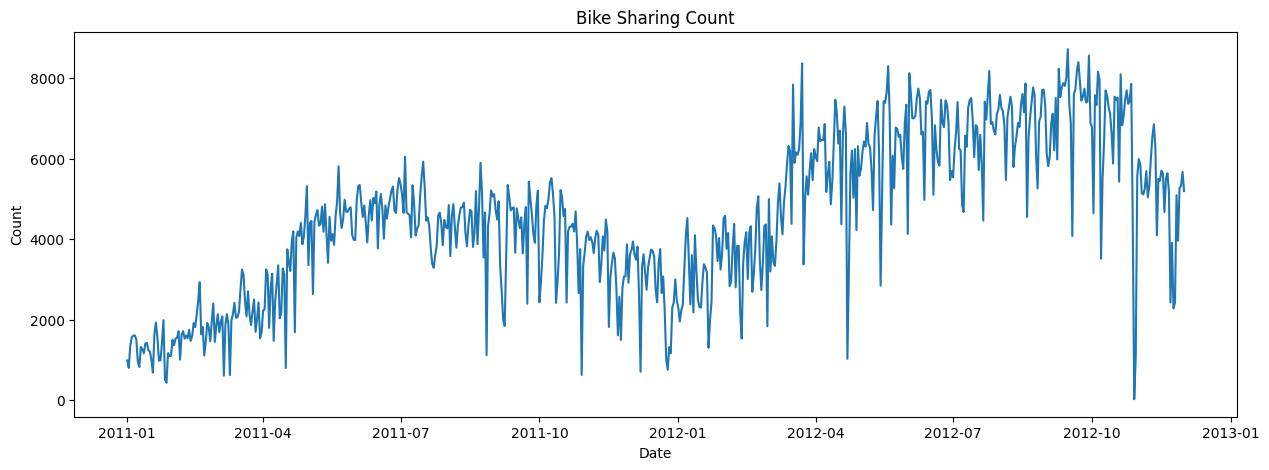

In [14]:
plt.figure(figsize = (15,5))
plt.plot(df_copy['y'])
plt.title('Bike Sharing Count')
plt.xlabel('Date')
plt.ylabel('Count')
plt.show()


In [15]:
df_copy = df_copy.asfreq('D')

# Month and Quarter Plots

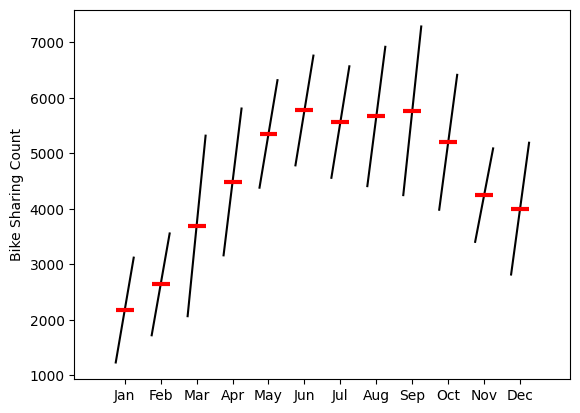

In [16]:
month_plot(df_copy['y'].resample('ME').mean())
plt.ylabel('Bike Sharing Count')
plt.show()

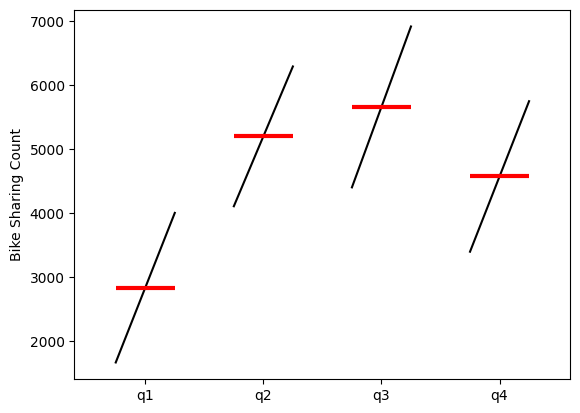

In [17]:
# Plot the quarter_plot
quarter_plot(df_copy['y'].resample('QE').mean())
plt.ylabel('Bike Sharing Count')
plt.show()


# Seasonal Decomposition

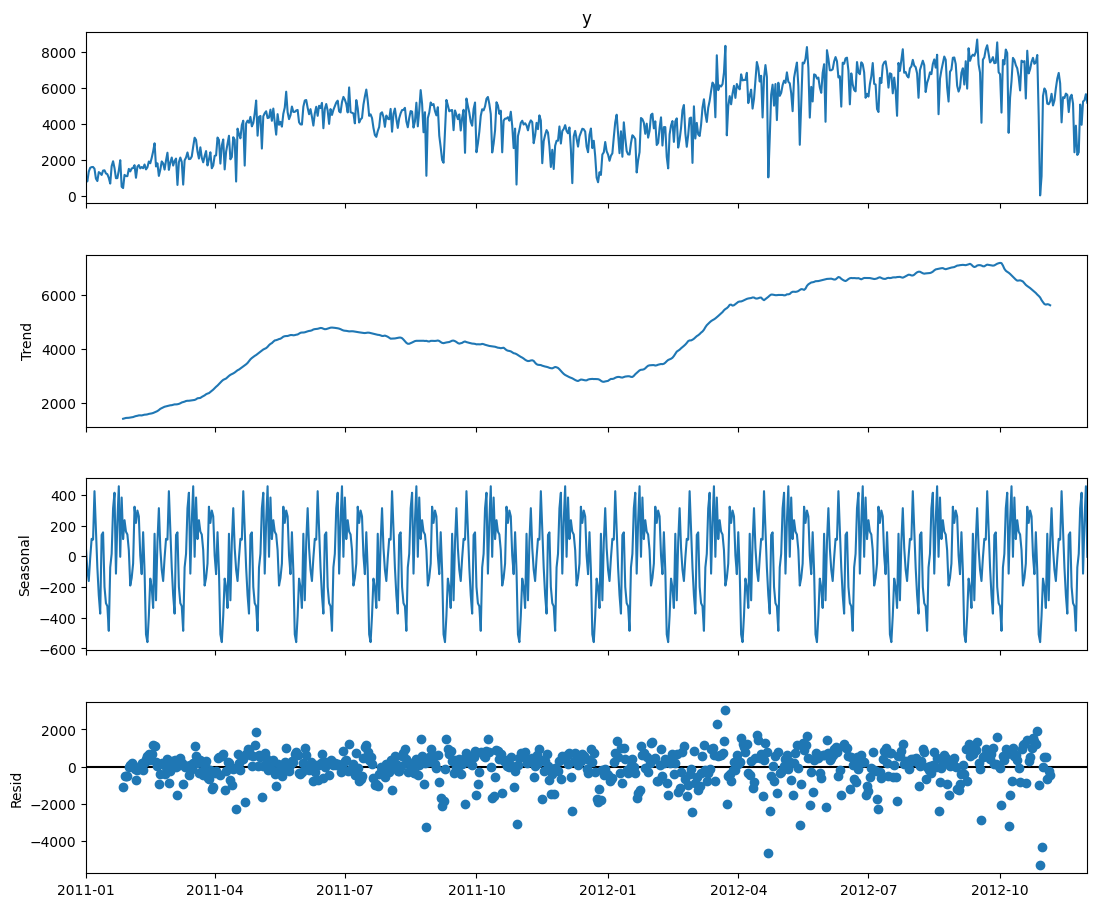

In [18]:
# Seasonal decomposition for df_copy['y']
decomposition = seasonal_decompose(df_copy['y'],
                                  model = 'additive',
                                  period = 52)
fig = decomposition.plot()
fig.set_size_inches(12, 10)
plt.show()


# ACF & PACF

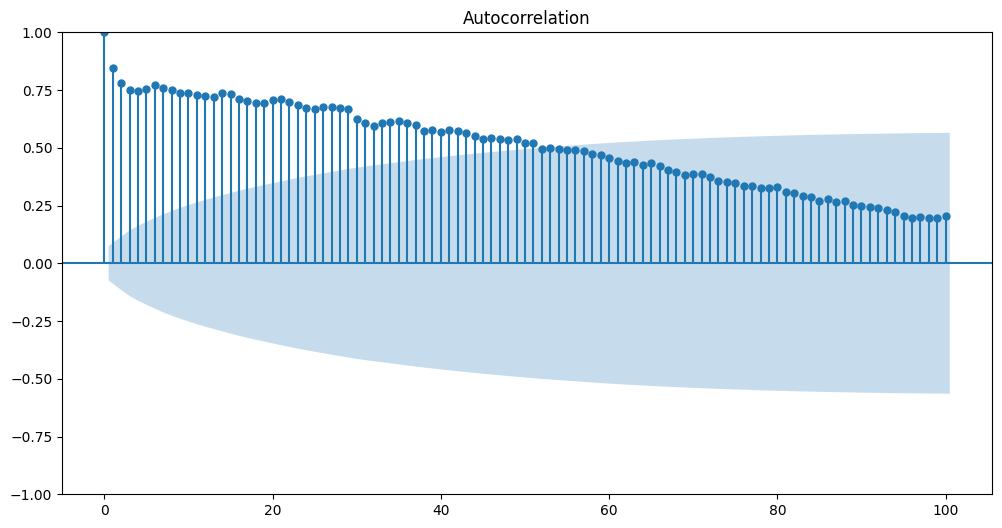

In [19]:
# Plot the ACF
fig, ax = plt.subplots(figsize = (12, 6))
plot_acf(df_copy['y'], lags = 100, ax = ax)
plt.show()


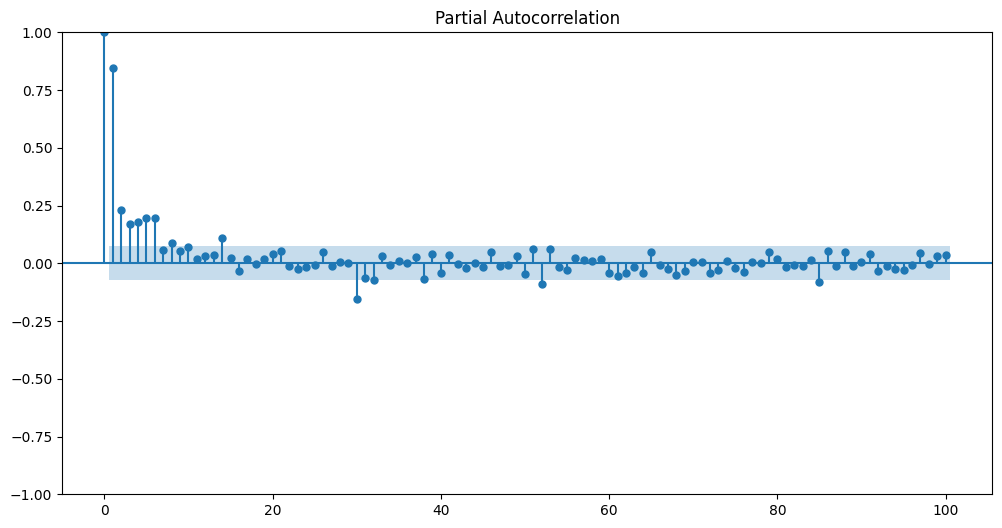

In [20]:
# PACF
fig, ax = plt.subplots(figsize = (12, 6))
plot_pacf(df_copy['y'], lags = 100, ax = ax)
plt.show()


# Stationarity

In [21]:
def adf_test(series, title=None):

  # Run the ADF test
  result = adfuller(series.dropna(), autolag='AIC')

  # Extract and print results
  print('ADF Statistic:', result[0])
  print('p-value:', result[1])
  print('Critical Values:')
  for key, value in result[4].items():
      print(f'   {key}: {value}')

  # Interpretation
  if result[1] < 0.05:
      print("Result: The series is likely stationary (reject H0).")
  else:
      print("Result: The series is likely non-stationary (fail to reject H0).")

In [22]:
adf_test(df_copy['y'])

ADF Statistic: -2.018517628160553
p-value: 0.2785132482853734
Critical Values:
   1%: -3.439904442607456
   5%: -2.8657562268758907
   10%: -2.569015252972123
Result: The series is likely non-stationary (fail to reject H0).


Let's compute the difference of `df_copy.y`

In [23]:
df_copy['y_diff'] = df_copy['y'].diff().dropna()
df_copy.head()


,holiday,workingday,weathersit,temp,atemp,hum,windspeed,y,y_diff
2011-01-01,0,0,2,0.344167,0.363625,0.805833,0.160446,985,NaN
2011-01-02,0,0,2,0.363478,0.353739,0.696087,0.248539,801,-184.0
2011-01-03,0,1,1,0.196364,0.189405,0.437273,0.248309,1349,548.0
2011-01-04,0,1,1,0.200000,0.212122,0.590435,0.160296,1562,213.0
2011-01-05,0,1,1,0.226957,0.229270,0.436957,0.186900,1600,38.0


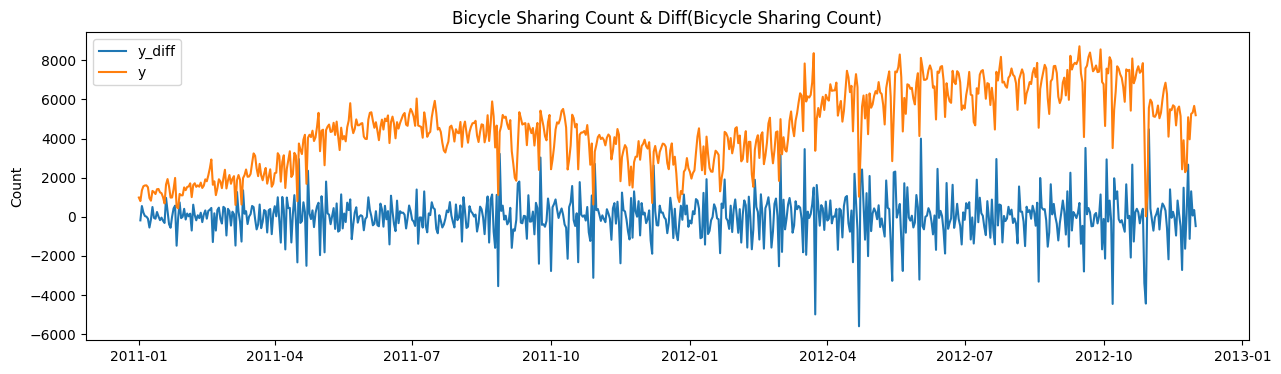

In [24]:
plt.figure(figsize = (15,4))
plt.plot(df_copy['y_diff'],label='y_diff')
plt.plot(df_copy['y'],label='y')
plt.legend()
plt.title("Bicycle Sharing Count & Diff(Bicycle Sharing Count)")
plt.ylabel("Count")
plt.show()

In [25]:
adf_test(df_copy['y_diff'])

ADF Statistic: -11.927665998038732
p-value: 4.863930539976842e-22
Critical Values:
   1%: -3.439904442607456
   5%: -2.8657562268758907
   10%: -2.569015252972123
Result: The series is likely stationary (reject H0).


# Holidays in the dataframe

In [26]:
df[df.holiday == 1].ds

,ds
16,2011-01-17
51,2011-02-21
104,2011-04-15
149,2011-05-30
184,2011-07-04
247,2011-09-05
282,2011-10-10
314,2011-11-11
327,2011-11-24
359,2011-12-26


Some of these holidays need to be defined further so we will define various holiday intervals.

In [27]:
# general holiday
gen_holidays = pd.DataFrame({'holiday': 'gen_holi',
                             'ds': df[df.holiday == 1].ds,
                             'lower_window': -2,
                             'upper_window': 2})
# Christmas
christmas = pd.DataFrame({'holiday': 'christmas',
                     'ds': pd.to_datetime(['2011-12-24', '2012-12-24']),
                             'lower_window': -5,
                             'upper_window': 3})
# New Year's eve
new_years = pd.DataFrame({'holiday': 'new_years',
                     'ds': pd.to_datetime(['2011-12-31', '2012-12-31']),
                             'lower_window': -3,
                             'upper_window': 3})
# Easter
easter = pd.DataFrame({'holiday': 'easter',
                     'ds': pd.to_datetime(['2011-04-24', '2012-04-08']),
                     'lower_window': -3,
                             'upper_window': 3})

In [28]:
christmas.head()

,holiday,ds,lower_window,upper_window
0,christmas,2011-12-24,-5,3
1,christmas,2012-12-24,-5,3


In [29]:
holidays = pd.concat([gen_holidays, christmas, new_years, easter])
holidays.head()

,holiday,ds,lower_window,upper_window
16,gen_holi,2011-01-17,-2,2
51,gen_holi,2011-02-21,-2,2
104,gen_holi,2011-04-15,-2,2
149,gen_holi,2011-05-30,-2,2
184,gen_holi,2011-07-04,-2,2


# Feature Engineering

Let's look at lags in the `temp` and `atemp` features:

In [30]:
for lag in [1,3,5,7]:
  df[f'temp_lag_{lag}'] = df['temp'].shift(lag)
  df[f'atemp_lag_{lag}'] = df['atemp'].shift(lag)
df.head()

,holiday,workingday,temp,atemp,hum,windspeed,y,ds,weathersit_2,weathersit_3,temp_lag_1,atemp_lag_1,temp_lag_3,atemp_lag_3,temp_lag_5,atemp_lag_5,temp_lag_7,atemp_lag_7
0,0,0,0.344167,0.363625,0.805833,0.160446,985,2011-01-01,True,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,0,0.363478,0.353739,0.696087,0.248539,801,2011-01-02,True,False,0.344167,0.363625,NaN,NaN,NaN,NaN,NaN,NaN
2,0,1,0.196364,0.189405,0.437273,0.248309,1349,2011-01-03,False,False,0.363478,0.353739,NaN,NaN,NaN,NaN,NaN,NaN
3,0,1,0.200000,0.212122,0.590435,0.160296,1562,2011-01-04,False,False,0.196364,0.189405,0.344167,0.363625,NaN,NaN,NaN,NaN
4,0,1,0.226957,0.229270,0.436957,0.186900,1600,2011-01-05,False,False,0.200000,0.212122,0.363478,0.353739,NaN,NaN,NaN,NaN


Check correlations

In [31]:
# Create correlation matrix between the lagged values and y

columns = ['y'] + [col for col in df.columns if col.startswith('temp_lag_') or col.startswith('atemp_lag_')]
corr_matrix = df[columns].corr()
corr_matrix

,y,temp_lag_1,atemp_lag_1,temp_lag_3,atemp_lag_3,temp_lag_5,atemp_lag_5,temp_lag_7,atemp_lag_7
y,1.000000,0.590368,0.586681,0.581922,0.577076,0.589976,0.587374,0.595830,0.591886
temp_lag_1,0.590368,1.000000,0.991526,0.892245,0.882663,0.861173,0.847990,0.864545,0.852673
atemp_lag_1,0.586681,0.991526,1.000000,0.877489,0.869430,0.848465,0.836607,0.853113,0.842372
temp_lag_3,0.581922,0.892245,0.877489,1.000000,0.991519,0.891829,0.882187,0.860613,0.847451
atemp_lag_3,0.577076,0.882663,0.869430,0.991519,1.000000,0.877082,0.868989,0.847940,0.836076
temp_lag_5,0.589976,0.861173,0.848465,0.891829,0.877082,1.000000,0.991490,0.891432,0.881814
atemp_lag_5,0.587374,0.847990,0.836607,0.882187,0.868989,0.991490,1.000000,0.876584,0.868539
temp_lag_7,0.595830,0.864545,0.853113,0.860613,0.847940,0.891432,0.876584,1.000000,0.991475
atemp_lag_7,0.591886,0.852673,0.842372,0.847451,0.836076,0.881814,0.868539,0.991475,1.000000


Upon inspection of the correlation matrix, we see that all of the lags have a correlation with $y \approx 0.59$. Also, we see that correlation between `temp` and `atemp` is almost 1, so we can drop 1 of these variables. So we will just keep `temp_lag_1`.

In [32]:
df.drop(['temp_lag_3', 'temp_lag_5','temp_lag_7','atemp_lag_1', 'atemp_lag_3', 'atemp_lag_5', 'atemp_lag_7'], axis=1, inplace=True)
df.head()

,holiday,workingday,temp,atemp,hum,windspeed,y,ds,weathersit_2,weathersit_3,temp_lag_1
0,0,0,0.344167,0.363625,0.805833,0.160446,985,2011-01-01,True,False,NaN
1,0,0,0.363478,0.353739,0.696087,0.248539,801,2011-01-02,True,False,0.344167
2,0,1,0.196364,0.189405,0.437273,0.248309,1349,2011-01-03,False,False,0.363478
3,0,1,0.200000,0.212122,0.590435,0.160296,1562,2011-01-04,False,False,0.196364
4,0,1,0.226957,0.229270,0.436957,0.186900,1600,2011-01-05,False,False,0.200000


# Prophet Model

Drop any rows in the dataframe that contain null values as the Prophet model cannot handle them.

In [33]:
df.dropna(inplace=True)

In [34]:
model_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    holidays=holidays,
    seasonality_mode='multiplicative',
    seasonality_prior_scale=10,
    holidays_prior_scale=10,
    changepoint_prior_scale=0.05
    )
model_prophet.add_regressor('workingday')
model_prophet.add_regressor('temp')
model_prophet.add_regressor('atemp')
model_prophet.add_regressor('hum')
model_prophet.add_regressor('windspeed')
model_prophet.add_regressor('weathersit_2')
model_prophet.add_regressor('weathersit_3')
model_prophet.add_regressor('temp_lag_1')

model_prophet.fit(df)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp72qk08l5/ayh7j48m.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp72qk08l5/i191b48x.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=19468', 'data', 'file=/tmp/tmp72qk08l5/ayh7j48m.json', 'init=/tmp/tmp72qk08l5/i191b48x.json', 'output', 'file=/tmp/tmp72qk08l5/prophet_modelgmbtvd51/prophet_model-20250730234946.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
23:49:46 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
23:49:47 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [35]:
# Get Regressor Coefficients

from prophet.utilities import regressor_coefficients
coef_df = regressor_coefficients(model_prophet)

Interpreting the Coefficients

In [36]:
def interpret_multiplicative_coeffs(df):
    interpretations = []

    for _, row in df.iterrows():
        reg = row['regressor']
        coef = row['coef']
        center = row['center']

        # Direction of effect
        direction = "increases" if coef > 0 else "decreases" if coef < 0 else "has no effect on"

        # Strength descriptor
        magnitude = abs(coef)
        if magnitude > 0.7:
            strength = "strongly"
        elif magnitude > 0.3:
            strength = "moderately"
        elif magnitude > 0:
            strength = "weakly"
        else:
            strength = "negligibly"

        # Special handling for binary or categorical features
        if reg.startswith('weathersit_'):
            context = f"When weather situation is category {reg[-1]}, demand {direction} {strength}."
        elif reg == 'workingday':
            context = f"On a working day, demand {direction} {strength}."
        else:
            context = (f"A unit increase in '{reg}' (from centered value {center:.2f}) "
                       f"{direction} demand {strength} in a multiplicative way.")

        interpretations.append(context)

    return interpretations


In [37]:
interpret_multiplicative_coeffs(coef_df)

['On a working day, demand increases moderately.',
 "A unit increase in 'temp' (from centered value 0.50) increases demand strongly in a multiplicative way.",
 "A unit increase in 'atemp' (from centered value 0.48) increases demand moderately in a multiplicative way.",
 "A unit increase in 'hum' (from centered value 0.63) decreases demand moderately in a multiplicative way.",
 "A unit increase in 'windspeed' (from centered value 0.19) decreases demand moderately in a multiplicative way.",
 'When weather situation is category 2, demand decreases weakly.',
 'When weather situation is category 3, demand decreases moderately.',
 "A unit increase in 'temp_lag_1' (from centered value 0.50) decreases demand moderately in a multiplicative way."]

# Cross Validation

How many days does the dataset contain?

In [38]:
df.shape[0]

700

In [39]:
from prophet.diagnostics import cross_validation
df_cv = cross_validation(model_prophet,
                         period='15 days',
                         initial='521 days',
                         horizon='30 days',
                         parallel='processes')

INFO:prophet:Making 10 forecasts with cutoffs between 2012-06-19 00:00:00 and 2012-11-01 00:00:00
INFO:prophet:Applying in parallel with <concurrent.futures.process.ProcessPoolExecutor object at 0x7ed054aa2350>
DEBUG:cmdstanpy:input tempfile: /tmp/tmp72qk08l5/n9cgcofj.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp72qk08l5/ssvbk132.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp72qk08l5/lb7t6j0j.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=67288', 'data', 'file=/tmp/tmp72qk08l5/n9cgcofj.json', 'init=/tmp/tmp72qk08l5/lb7t6j0j.json', 'output', 'file=/tmp/tmp72qk08l5/prophet_modelx4o_tenn/prophet_model-20250730234947.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
DEBUG:cmdstanpy:input tempfile: /tmp/tmp72qk08l5/cbpe49a5.json
DEBUG:cmdstanpy:idx 0
23:49:47 - cmdstanpy - INFO - Chain [1] start processing
DEBUG:cmdstanpy:runnin

In [40]:
df_cv.head()

,ds,yhat,yhat_lower,yhat_upper,y,cutoff
0,2012-06-20,8218.107965,7524.212103,8882.725190,6211,2012-06-19
1,2012-06-21,8517.636438,7855.605367,9239.885908,5905,2012-06-19
2,2012-06-22,8155.284540,7455.383090,8810.014059,5823,2012-06-19
3,2012-06-23,7738.209754,7010.537811,8415.677152,7458,2012-06-19
4,2012-06-24,7891.994019,7182.797457,8619.654890,6891,2012-06-19


Calculate performance metrics

In [41]:
from prophet.diagnostics import performance_metrics
df_p = performance_metrics(df_cv)
df_p.head(100)

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,3 days,1.591031e+06,1261.360842,1000.132174,0.174698,0.124849,0.166258,0.533333
1,4 days,1.426143e+06,1194.212092,934.742984,0.156520,0.116548,0.151778,0.533333
2,5 days,1.471865e+06,1213.204488,966.709165,0.157546,0.110663,0.153219,0.466667
3,6 days,1.146910e+06,1070.938755,852.419013,0.132846,0.089614,0.134467,0.533333
4,7 days,1.236445e+06,1111.955466,868.194133,0.131164,0.089614,0.136146,0.566667
5,8 days,1.001902e+06,1000.950416,764.596263,0.107564,0.087141,0.115711,0.633333
6,9 days,9.584884e+05,979.024188,763.311539,0.107518,0.093548,0.114192,0.600000
7,10 days,1.401179e+06,1183.713884,888.127403,0.128911,0.096708,0.131643,0.533333
8,11 days,1.492019e+06,1221.482273,908.185192,0.135645,0.096017,0.136172,0.600000
9,12 days,1.925474e+06,1387.614608,1072.709699,0.168293,0.115892,0.171555,0.500000


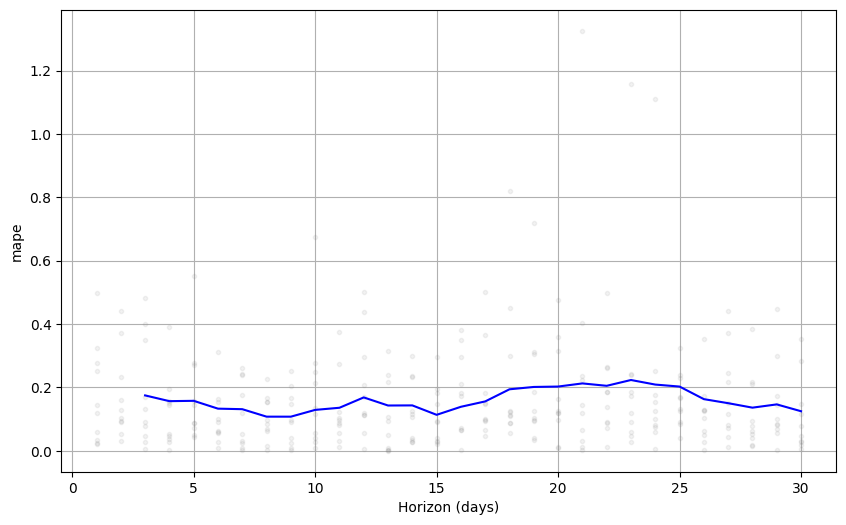

In [42]:
from prophet.plot import plot_cross_validation_metric
fig = plot_cross_validation_metric(df_cv, metric='mape')

Let's explore this error...

The biggest percentage deviation seems to be happening on 10/29/2012.  What happened on that day?

It turns out that Hurricane Sandy hit Washington DC on that day.

In [43]:
# Compute the error/deviation

df_cv['deviation_%'] = (abs(df_cv['yhat'] - df_cv['y'])/df_cv['y'])*100
df_cv.sort_values(by='deviation_%', ascending=False).head()

,ds,yhat,yhat_lower,yhat_upper,y,cutoff,deviation_%
290,2012-11-22,5640.385320,4794.578954,6435.672366,2425,2012-11-01,132.593209
292,2012-11-24,4910.404855,4106.538786,5698.051868,2277,2012-11-01,115.652387
293,2012-11-25,5112.630094,4277.847883,5895.866925,2424,2012-11-01,110.917083
17,2012-07-07,8801.463540,8117.995380,9507.715457,4840,2012-06-19,81.848420
18,2012-07-08,8028.202612,7326.559692,8741.031396,4672,2012-06-19,71.836529


In [44]:
df[df['ds'].isin(['2012-10-29','2012-10-30'])]

,holiday,workingday,temp,atemp,hum,windspeed,y,ds,weathersit_2,weathersit_3,temp_lag_1
667,0,1,0.440000,0.439400,0.880000,0.358200,4459,2012-10-29,False,True,0.4775
668,0,1,0.318182,0.309909,0.825455,0.213009,4459,2012-10-30,True,False,0.4400


We really do not have any insight as to why the deviation is so high for 10/29 and 10/30 so what we will do is impute the $y$ value on 10/28 for this dates.

# Model Parameter Tuning

In [45]:
# Define the parameter grid to search

param_grid = {  'changepoint_prior_scale': [0.05, 0.5],
                'seasonality_prior_scale': [10, 20],
                'holidays_prior_scale': [10, 20],
                'seasonality_mode': ['additive', 'multiplicative']
             }

In [46]:
# Generate all combinations of parameters

from sklearn.model_selection import ParameterGrid

all_params = list(ParameterGrid(param_grid))
len(all_params)
all_params

[{'changepoint_prior_scale': 0.05,
  'holidays_prior_scale': 10,
  'seasonality_mode': 'additive',
  'seasonality_prior_scale': 10},
 {'changepoint_prior_scale': 0.05,
  'holidays_prior_scale': 10,
  'seasonality_mode': 'additive',
  'seasonality_prior_scale': 20},
 {'changepoint_prior_scale': 0.05,
  'holidays_prior_scale': 10,
  'seasonality_mode': 'multiplicative',
  'seasonality_prior_scale': 10},
 {'changepoint_prior_scale': 0.05,
  'holidays_prior_scale': 10,
  'seasonality_mode': 'multiplicative',
  'seasonality_prior_scale': 20},
 {'changepoint_prior_scale': 0.05,
  'holidays_prior_scale': 20,
  'seasonality_mode': 'additive',
  'seasonality_prior_scale': 10},
 {'changepoint_prior_scale': 0.05,
  'holidays_prior_scale': 20,
  'seasonality_mode': 'additive',
  'seasonality_prior_scale': 20},
 {'changepoint_prior_scale': 0.05,
  'holidays_prior_scale': 20,
  'seasonality_mode': 'multiplicative',
  'seasonality_prior_scale': 10},
 {'changepoint_prior_scale': 0.05,
  'holidays_prio

In [47]:
# Create a empty list for storing the tuning results

tuning_results = []

for params in all_params:

  # Build the model

  model_prophet = Prophet(
                          yearly_seasonality=True,
                          weekly_seasonality=True,
                          holidays=holidays,
                          **params
                          )
  model_prophet.add_regressor('workingday')
  model_prophet.add_regressor('temp')
  model_prophet.add_regressor('atemp')
  model_prophet.add_regressor('hum')
  model_prophet.add_regressor('windspeed')
  model_prophet.add_regressor('weathersit_2')
  model_prophet.add_regressor('weathersit_3')
  model_prophet.add_regressor('temp_lag_1')

  model_prophet.fit(df)

  # Cross Validation

  df_cv = cross_validation(model_prophet,
                         period='15 days',
                         initial='521 days',
                         horizon='30 days',
                         parallel='processes')

  # Compute and store the error

  rmse = performance_metrics(df_cv)['rmse'].mean()
  tuning_results.append(rmse)



INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp72qk08l5/4eatjytk.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp72qk08l5/4j03vr5j.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=57804', 'data', 'file=/tmp/tmp72qk08l5/4eatjytk.json', 'init=/tmp/tmp72qk08l5/4j03vr5j.json', 'output', 'file=/tmp/tmp72qk08l5/prophet_modeldk5450m4/prophet_model-20250730234951.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
23:49:51 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
23:49:52 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
INFO:prophet:Making 10 forecasts with cutoffs between 2012-06-19 00:00:00 and 2012-11-01 00:00:00
INFO:prophet:Applying in parallel with <conc

In [48]:
tuning_results_df = pd.DataFrame(all_params)
tuning_results_df['rmse'] = tuning_results
tuning_results_df.sort_values(by='rmse', ascending=True)

,changepoint_prior_scale,holidays_prior_scale,seasonality_mode,seasonality_prior_scale,rmse
5,0.05,20,additive,20,981.739288
1,0.05,10,additive,20,981.874867
4,0.05,20,additive,10,982.518742
0,0.05,10,additive,10,983.910230
8,0.50,10,additive,10,1139.211725
13,0.50,20,additive,20,1140.853440
12,0.50,20,additive,10,1148.765937
9,0.50,10,additive,20,1153.066027
6,0.05,20,multiplicative,10,1263.027453
3,0.05,10,multiplicative,20,1263.087048


In [49]:
# Fetch the best model paramters

best_params = tuning_results_df.loc[tuning_results_df['rmse'].idxmin()]
best_params

,5
changepoint_prior_scale,0.05
holidays_prior_scale,20
seasonality_mode,additive
seasonality_prior_scale,20
rmse,981.739288


# Predict the Future Using the Trained Model

In [50]:
# Load in train dataset
df_train = pd.read_csv('/gdrive/MyDrive/Colab_Notebooks/Time Series Analysis/Python - Time Series Forecasting/Modern Time Series Forecasting Techniques /Prophet/Daily Bike Sharing training.csv')
df_train.head()


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,1/1/2011,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,1/2/2011,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,1/3/2011,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,1/4/2011,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,1/5/2011,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [51]:
# Load in the future dataset
df_future = pd.read_csv('/gdrive/MyDrive/Colab_Notebooks/Time Series Analysis/Python - Time Series Forecasting/Modern Time Series Forecasting Techniques /Prophet/Daily Bike Sharing future.csv')
df_future.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,702,12/2/2012,4,1,12,0,0,0,2,0.347500,0.359208,0.823333,0.124379,NaN,NaN,NaN
1,703,12/3/2012,4,1,12,0,1,1,1,0.452500,0.455796,0.767500,0.082721,NaN,NaN,NaN
2,704,12/4/2012,4,1,12,0,2,1,1,0.475833,0.469054,0.733750,0.174129,NaN,NaN,NaN
3,705,12/5/2012,4,1,12,0,3,1,1,0.438333,0.428012,0.485000,0.324021,NaN,NaN,NaN
4,706,12/6/2012,4,1,12,0,4,1,1,0.255833,0.258204,0.508750,0.174754,NaN,NaN,NaN


We need to concat `df_train` and `df_future`.

In [52]:
df = pd.concat([df_train, df_future])
df.reset_index(drop=True, inplace=True)  # need to reset the indices of df_future to follow df_train
df.tail()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
726,727,12/27/2012,1,1,12,0,4,1,2,0.254167,0.226642,0.652917,0.350133,NaN,NaN,NaN
727,728,12/28/2012,1,1,12,0,5,1,2,0.253333,0.255046,0.590000,0.155471,NaN,NaN,NaN
728,729,12/29/2012,1,1,12,0,6,0,2,0.253333,0.242400,0.752917,0.124383,NaN,NaN,NaN
729,730,12/30/2012,1,1,12,0,0,0,1,0.255833,0.231700,0.483333,0.350754,NaN,NaN,NaN
730,731,12/31/2012,1,1,12,0,1,1,2,0.215833,0.223487,0.577500,0.154846,NaN,NaN,NaN


In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      701 non-null    float64
 14  registered  701 non-null    float64
 15  cnt         701 non-null    float64
dtypes: float64(7), int64(8), object(1)
memory usage: 91.5+ KB


So now we need to perform the same dataframe transformations that we did earlier...

In [54]:
df['y'] = df['cnt']
df['ds'] = df['dteday']
df['ds'] = pd.to_datetime(df['ds'],format='%m/%d/%Y')
df.drop(['cnt','dteday'], axis=1, inplace=True)
df.head()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,y,ds
0,1,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331.0,654.0,985.0,2011-01-01
1,2,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131.0,670.0,801.0,2011-01-02
2,3,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120.0,1229.0,1349.0,2011-01-03
3,4,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108.0,1454.0,1562.0,2011-01-04
4,5,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82.0,1518.0,1600.0,2011-01-05


In [55]:
weather_sit = pd.get_dummies(df['weathersit'], drop_first=True, prefix='weathersit')
df = pd.concat([df, weather_sit], axis=1)
df.drop(['weathersit'], axis=1, inplace=True)
df.head()

,instant,season,yr,mnth,holiday,weekday,workingday,temp,atemp,hum,windspeed,casual,registered,y,ds,weathersit_2,weathersit_3
0,1,1,0,1,0,6,0,0.344167,0.363625,0.805833,0.160446,331.0,654.0,985.0,2011-01-01,True,False
1,2,1,0,1,0,0,0,0.363478,0.353739,0.696087,0.248539,131.0,670.0,801.0,2011-01-02,True,False
2,3,1,0,1,0,1,1,0.196364,0.189405,0.437273,0.248309,120.0,1229.0,1349.0,2011-01-03,False,False
3,4,1,0,1,0,2,1,0.200000,0.212122,0.590435,0.160296,108.0,1454.0,1562.0,2011-01-04,False,False
4,5,1,0,1,0,3,1,0.226957,0.229270,0.436957,0.186900,82.0,1518.0,1600.0,2011-01-05,False,False


In [56]:
df.drop(columns = ['instant','season','mnth','yr','weekday','casual','registered'],inplace=True)
df.head()

,holiday,workingday,temp,atemp,hum,windspeed,y,ds,weathersit_2,weathersit_3
0,0,0,0.344167,0.363625,0.805833,0.160446,985.0,2011-01-01,True,False
1,0,0,0.363478,0.353739,0.696087,0.248539,801.0,2011-01-02,True,False
2,0,1,0.196364,0.189405,0.437273,0.248309,1349.0,2011-01-03,False,False
3,0,1,0.200000,0.212122,0.590435,0.160296,1562.0,2011-01-04,False,False
4,0,1,0.226957,0.229270,0.436957,0.186900,1600.0,2011-01-05,False,False


In [57]:
new_y_val = df.loc[df['ds'] == '2012-10-28'].y.values[0]
new_y_val

np.float64(4459.0)

In [58]:
df.loc[df['ds'].isin(['2012-10-29', '2012-10-30']), 'y'] = new_y_val
df[df['ds'].isin(['2012-10-28','2012-10-29', '2012-10-30'])].y

,y
666,4459.0
667,4459.0
668,4459.0


In [59]:
# general holiday
gen_holidays = pd.DataFrame({'holiday': 'gen_holi',
                             'ds': df[df.holiday == 1].ds,
                             'lower_window': -2,
                             'upper_window': 2})
# Christmas
christmas = pd.DataFrame({'holiday': 'christmas',
                     'ds': pd.to_datetime(['2011-12-24', '2012-12-24']),
                             'lower_window': -5,
                             'upper_window': 3})
# New Year's eve
new_years = pd.DataFrame({'holiday': 'new_years',
                     'ds': pd.to_datetime(['2011-12-31', '2012-12-31']),
                             'lower_window': -3,
                             'upper_window': 3})
# Easter
easter = pd.DataFrame({'holiday': 'easter',
                     'ds': pd.to_datetime(['2011-04-24', '2012-04-08']),
                     'lower_window': -3,
                             'upper_window': 3})

In [60]:
lag=1  # determined from previous EDA

df[f'temp_lag_{lag}'] = df['temp'].shift(lag)
df.head()

,holiday,workingday,temp,atemp,hum,windspeed,y,ds,weathersit_2,weathersit_3,temp_lag_1
0,0,0,0.344167,0.363625,0.805833,0.160446,985.0,2011-01-01,True,False,NaN
1,0,0,0.363478,0.353739,0.696087,0.248539,801.0,2011-01-02,True,False,0.344167
2,0,1,0.196364,0.189405,0.437273,0.248309,1349.0,2011-01-03,False,False,0.363478
3,0,1,0.200000,0.212122,0.590435,0.160296,1562.0,2011-01-04,False,False,0.196364
4,0,1,0.226957,0.229270,0.436957,0.186900,1600.0,2011-01-05,False,False,0.200000


Submit the training data to the tuned Prophet model.

In [61]:
df_train = df.iloc[:-30]
df_train.dropna(inplace=True)

In [62]:
# Remove the 'rmse' key from best_params as Prophet does not accept it as a parameter
best_params_prophet = best_params.drop('rmse').to_dict()

model_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    holidays=holidays,
    **best_params_prophet
    )
model_prophet.add_regressor('workingday')
model_prophet.add_regressor('temp')
model_prophet.add_regressor('atemp')
model_prophet.add_regressor('hum')
model_prophet.add_regressor('windspeed')
model_prophet.add_regressor('weathersit_2')
model_prophet.add_regressor('weathersit_3')
model_prophet.add_regressor('temp_lag_1')

model_prophet.fit(df_train)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp72qk08l5/emrhsn71.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp72qk08l5/mckmpeul.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=82042', 'data', 'file=/tmp/tmp72qk08l5/emrhsn71.json', 'init=/tmp/tmp72qk08l5/mckmpeul.json', 'output', 'file=/tmp/tmp72qk08l5/prophet_modelv86xd406/prophet_model-20250730235145.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
23:51:46 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
23:51:46 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


# Generate Forecast

In [63]:
future_regressors = df.drop(columns = ['y','ds'])
future_regressors = future_regressors.dropna()
future_regressors.reset_index(drop=True, inplace=True)
future_regressors

,holiday,workingday,temp,atemp,hum,windspeed,weathersit_2,weathersit_3,temp_lag_1
0,0,0,0.363478,0.353739,0.696087,0.248539,True,False,0.344167
1,0,1,0.196364,0.189405,0.437273,0.248309,False,False,0.363478
2,0,1,0.200000,0.212122,0.590435,0.160296,False,False,0.196364
3,0,1,0.226957,0.229270,0.436957,0.186900,False,False,0.200000
4,0,1,0.204348,0.233209,0.518261,0.089565,False,False,0.226957
...,...,...,...,...,...,...,...,...,...
725,0,1,0.254167,0.226642,0.652917,0.350133,True,False,0.243333
726,0,1,0.253333,0.255046,0.590000,0.155471,True,False,0.254167
727,0,0,0.253333,0.242400,0.752917,0.124383,True,False,0.253333
728,0,0,0.255833,0.231700,0.483333,0.350754,False,False,0.253333


In [64]:
# Create a future dataframe

future = model_prophet.make_future_dataframe(periods=30, freq='D')
future = pd.concat([future, future_regressors], axis=1)
future.tail()

,ds,holiday,workingday,temp,atemp,hum,windspeed,weathersit_2,weathersit_3,temp_lag_1
725,2012-12-27,0,1,0.254167,0.226642,0.652917,0.350133,True,False,0.243333
726,2012-12-28,0,1,0.253333,0.255046,0.590000,0.155471,True,False,0.254167
727,2012-12-29,0,0,0.253333,0.242400,0.752917,0.124383,True,False,0.253333
728,2012-12-30,0,0,0.255833,0.231700,0.483333,0.350754,False,False,0.253333
729,2012-12-31,0,1,0.215833,0.223487,0.577500,0.154846,True,False,0.255833


In [65]:
# Generate a forecast

forecast = model_prophet.predict(future)
forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,atemp,...,workingday,workingday_lower,workingday_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
725,2012-12-27,6538.031791,2422.667585,4091.021229,6537.543852,6538.614637,-3294.476013,-3294.476013,-3294.476013,-336.296339,...,643.293622,643.293622,643.293622,-514.715582,-514.715582,-514.715582,0.0,0.0,0.0,3243.555777
726,2012-12-28,6544.103884,3616.098462,5353.251947,6543.563614,6544.742953,-2024.784118,-2024.784118,-2024.784118,-298.744522,...,643.293622,643.293622,643.293622,-526.501737,-526.501737,-526.501737,0.0,0.0,0.0,4519.319765
727,2012-12-29,6550.175977,3270.028444,5019.334442,6549.582752,6550.867124,-2381.794412,-2381.794412,-2381.794412,-315.463304,...,0.000000,0.000000,0.000000,-538.233582,-538.233582,-538.233582,0.0,0.0,0.0,4168.381565
728,2012-12-30,6556.248071,3347.536364,5119.501421,6555.620521,6556.994491,-2314.515325,-2314.515325,-2314.515325,-329.609355,...,0.000000,0.000000,0.000000,-549.571199,-549.571199,-549.571199,0.0,0.0,0.0,4241.732745
729,2012-12-31,6562.320164,2429.452297,4114.264839,6561.635016,6563.128635,-3315.992289,-3315.992289,-3315.992289,-340.467441,...,643.293622,643.293622,643.293622,-560.204619,-560.204619,-560.204619,0.0,0.0,0.0,3246.327875


# Visualization of Generated Results

In [68]:
import plotly.express as px
fig = px.line(forecast, x='ds', y='yhat', title='Forecast with Prophet')
fig.show()

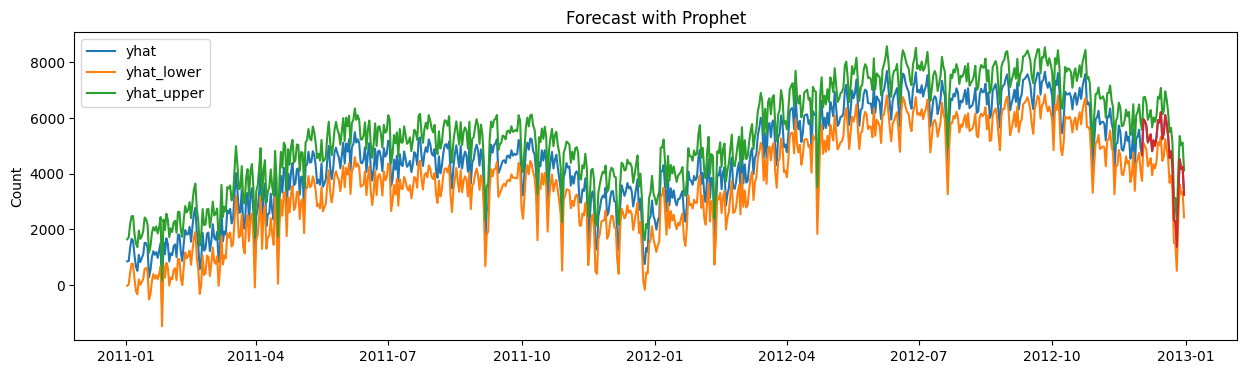

In [75]:
plt.figure(figsize = (15,4))
plt.plot(forecast['ds'], forecast['yhat'],label='yhat')
plt.plot(forecast['ds'], forecast['yhat_lower'],label='yhat_lower')
plt.plot(forecast['ds'], forecast['yhat_upper'],label='yhat_upper')
subset = forecast[forecast['ds'] > '2012-12-01']
plt.title("Forecast with Prophet")
plt.ylabel("Count")
plt.plot(subset['ds'], subset['yhat'])
plt.legend()
plt.show()


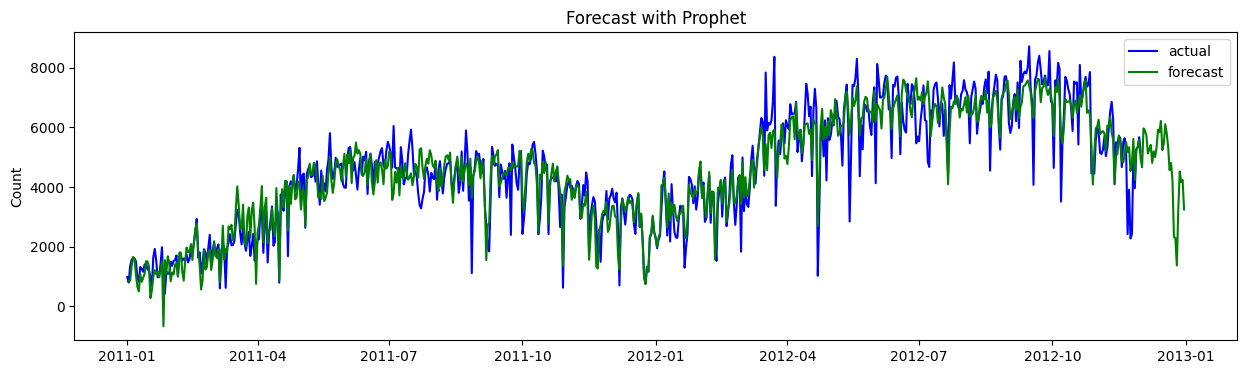

In [78]:
# Visualize time series plot

plt.figure(figsize = (15,4))
plt.plot(df['ds'], df['y'],label='actual',color='blue')
plt.plot(forecast['ds'], forecast['yhat'],label='forecast',color='green')
plt.title("Forecast with Prophet")
plt.ylabel("Count")
plt.legend()
plt.show()

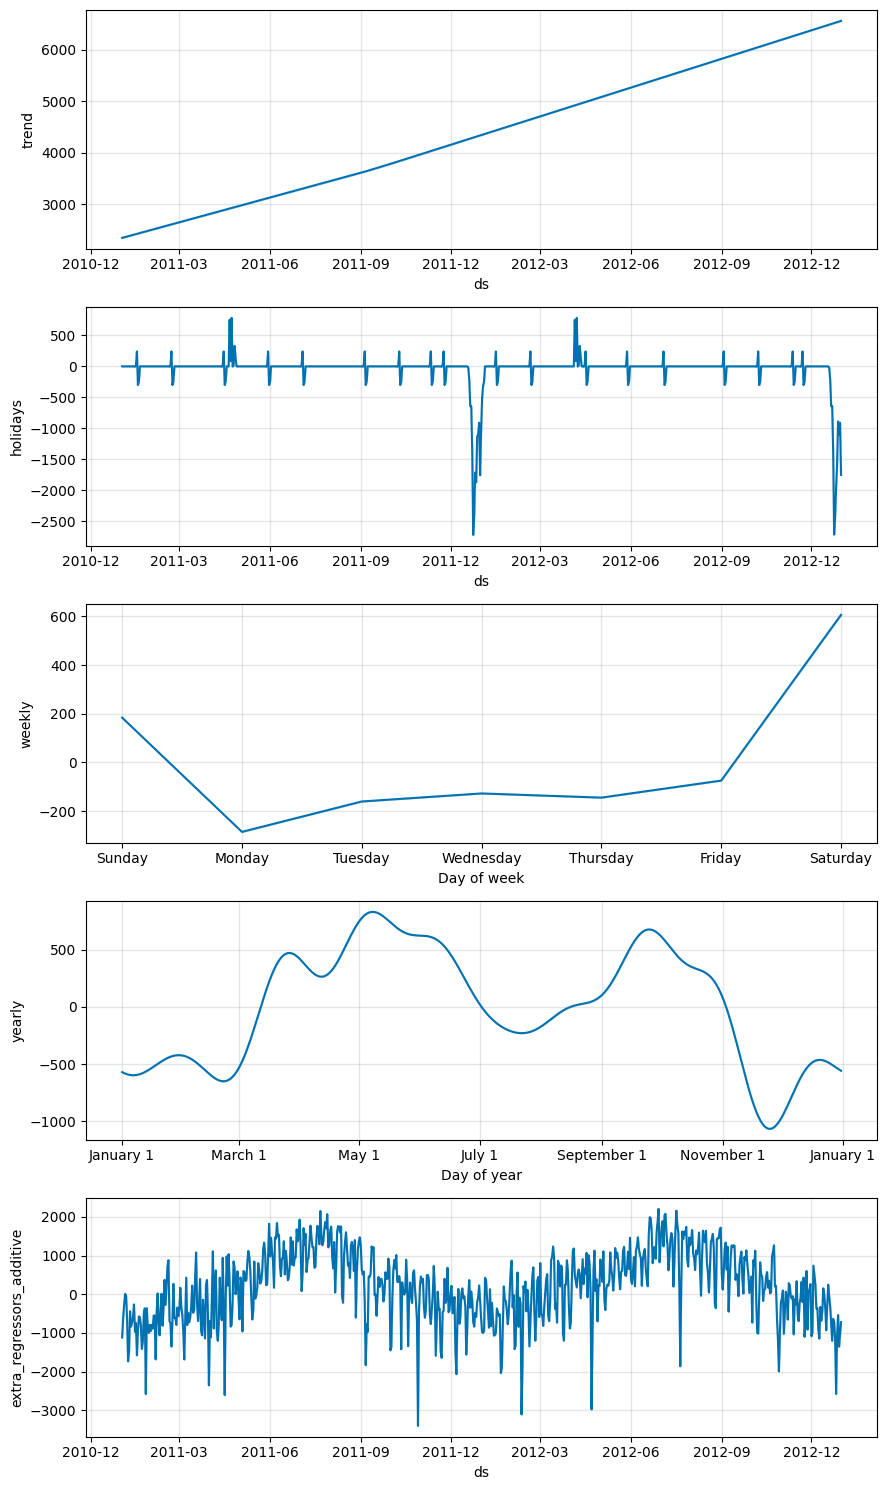

In [79]:
# Visualize components plot

model_prophet.plot_components(forecast)
plt.show()

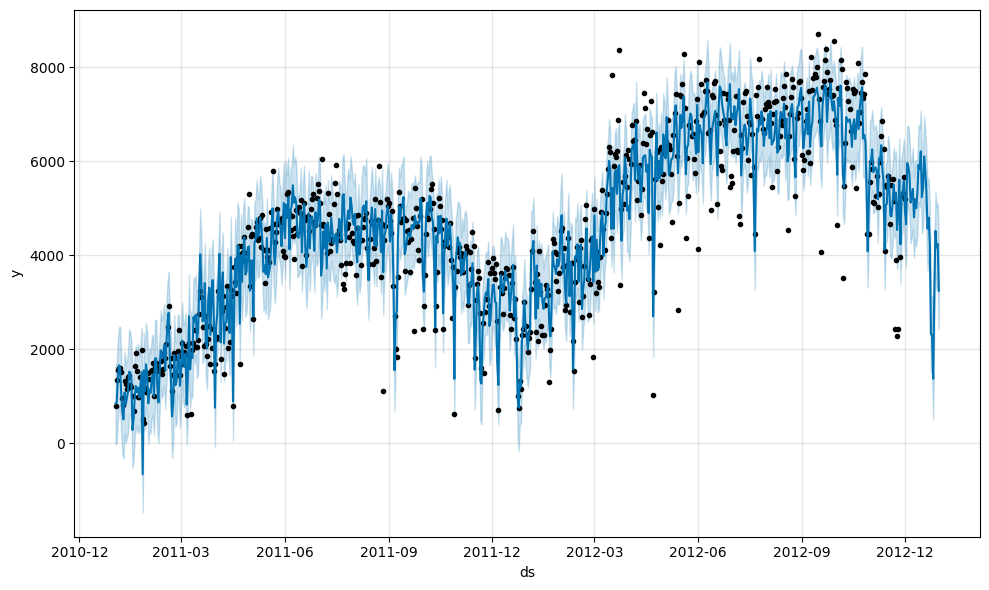

In [81]:
# Visualize forecast plot with uncertainty bounds

model_prophet.plot(forecast)
plt.show()

Plot residuals

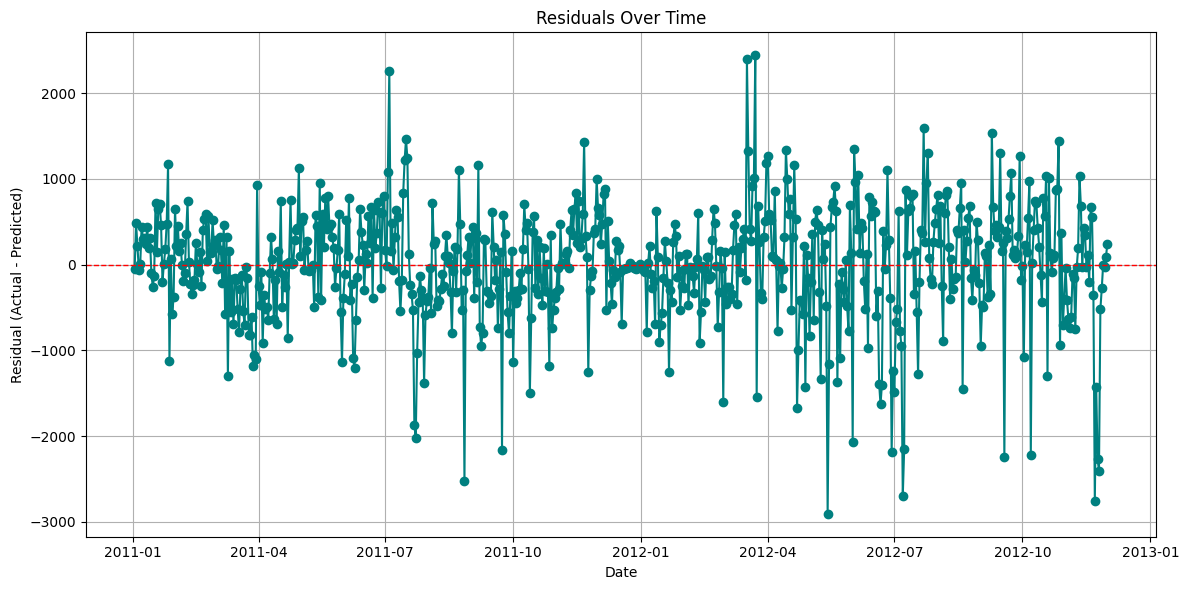

In [82]:
import matplotlib.pyplot as plt

# Merge actuals with forecast
df_merged = df[['ds', 'y']].merge(forecast[['ds', 'yhat']], on='ds')

# Calculate residuals
df_merged['residual'] = df_merged['y'] - df_merged['yhat']

# Plot residuals over time
plt.figure(figsize=(12, 6))
plt.plot(df_merged['ds'], df_merged['residual'], marker='o', linestyle='-', color='teal')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title('Residuals Over Time')
plt.xlabel('Date')
plt.ylabel('Residual (Actual - Predicted)')
plt.grid(True)
plt.tight_layout()
plt.show()